# Does drawing a trend line beat a moving average? 📉
### The "Linear Regression Channel" — the slope of a fitted line as a trend signal, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_moving_average%3F: Not_Supported](https://img.shields.io/badge/Beats_a_moving_average%3F-Not_Supported-8b949e?style=flat-square)

Open any charting app and you'll find the **Linear Regression Channel** (LRC): it fits a straight line through the last *N* days of price by least squares and draws a channel around it. The pitch is seductive — that fitted line's **slope** is a *smoother, faster* read on the trend than a laggy moving average. Up-slope → be long; down-slope → step aside. Surely a real regression beats a crude average?

We put the question on the tape: take **SPY** over 21 years, turn the 60-day regression slope into a long/flat timing rule, and **race it — net of costs — against (a) just buying and holding, and (b) the boring price-vs-moving-average rule it claims to improve on.** The honest answer is the usual one for chart-line folklore: it doesn't beat either, and the "better than a moving average" claim isn't supported.

> 📓 **Plain-language layer.** Want the *t*-stats, the permutation test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note.** SPY **total-return** (dividend-adjusted) daily closes via yfinance, cache-first. One execution lag (act on tomorrow's close). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from linear_regression_channel import data, strategy as st

HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    SPY = data.load_real("SPY", fetch=False)
    CLOSE = SPY["close"]
else:
    SPY = CLOSE = None
print("real SPY cache present:", HAVE_REAL,
      "| bars:", (0 if CLOSE is None else len(CLOSE)))

# frozen headline numbers (mirror of docs/results.md)
R = {'ticker': 'SPY', 'start': '2005-01-03', 'end': '2026-06-12', 'n_days': 5395, 'years': 21.4, 'fingerprint': 'aeda2bbca066', 'window': 60, 'cost_bps': 1.0, 'sharpe_bh': 0.647, 'cagr_bh': 11.08, 'slope': {'sharpe': 0.711, 'gap': 0.063, 'active_t': -1.51, 'tim': 72, 'turn_yr': 3.26, 'cagr_net': 7.81}, 'sma': {'sharpe': 0.604, 'gap': -0.043, 'active_t': -2.03, 'tim': 72, 'turn_yr': 15.92, 'cagr_net': 6.17}, 'perm_obs_bps': -1.641, 'perm_p': 0.676, 'cost': [(0.0, 0.713, 0.066, -1.5), (0.5, 0.712, 0.065, -1.51), (1.0, 0.711, 0.063, -1.51), (2.0, 0.708, 0.061, -1.53), (5.0, 0.699, 0.052, -1.56)], 'win': [(20, 0.552, -0.093, -2.23), (40, 0.465, -0.175, -2.44), (60, 0.711, 0.063, -1.51), (100, 0.595, -0.053, -1.91), (200, 0.711, 0.058, -1.03)], 'longshort': (0.205, -0.442, -1.54), 'panel': [('SPY', 0.711, 0.647, 0.063, -1.51), ('QQQ', 0.56, 0.793, -0.233, -3.01), ('AAPL', 0.959, 0.963, -0.004, -1.82), ('MSFT', 0.543, 0.683, -0.14, -2.36), ('JPM', 0.31, 0.543, -0.234, -2.51), ('XLE', 0.168, 0.404, -0.236, -1.96)], 'panel_beat': 1, 'panel_n': 6, 'syn': [(0.0, -0.028, 0.112, -0.14, -0.72, 0.714), (0.5, 2.263, 1.556, 0.706, 2.44, 0.0)]}


real SPY cache present: True | bars: 5395


## The answer first

| Question | Answer |
|---|---|
| Does the regression-slope rule beat **buy-and-hold**? | **No.** On SPY its net Sharpe is a hair higher (**0.71 vs 0.65**), but that gap is **not statistically real** — the head-to-head *t* is **negative** (−1.5), and on 5 of 6 other names the rule *loses*. |
| Does it beat a **moving average**? | **Not in any way that matters.** Both the slope rule and the price-vs-SMA rule fail to beat the market; the slope's only real difference is it **trades less** (lower turnover), not that it earns more. |
| Is the slope a *leading* trend read? | **No.** A 60-day regression slope is, by construction, a *smoothed average of the last 60 days* — it lags just like a moving average. |
| So is it worthless? | As an *alpha* source on a liquid index, **yes**. It's a fine way to *describe* a trend on a chart; it is **not** a way to beat the index. |

> The fitted line looks more "scientific" than a moving average. It isn't. Both are lagging trend filters, and on a market that mostly goes up, **staying invested** wins.

## 1 · The claim

> *"A moving average just averages the price — it lags. The **Linear Regression Channel** fits an actual trend line by least squares, so its **slope** tells you the trend's *direction and strength* sooner and cleaner. Go long when the slope turns up, flat (or short) when it turns down, and you'll ride trends better than any moving-average crossover."*

This is the standard write-up on TradingView, Investopedia and a thousand YouTube tutorials. It steelmans to a sharp, testable hypothesis: **the regression-slope timing rule earns a higher risk-adjusted return than (a) buy-and-hold and (b) the equivalent moving-average rule, net of costs.**

## 2 · So what?

If true, it would be a free upgrade: swap your moving average for a regression slope and get more return for the same risk, on the most liquid instrument on earth. It would also say something deep — that a *least-squares fit* extracts trend information the market hasn't priced.

But there's a trap hiding in plain sight. A regression slope over the last 60 days is **itself a weighted average of the last 60 days' returns** — it is a *cousin* of the moving average, not a different animal. So the real test isn't "does it make money" (in a 21-year bull market, almost any long-biased rule does); it's **"does it beat the market it's trading, after costs?"** — and is it any better than the moving average it claims to replace? We'll measure both, head-to-head.

## 3 · How would we even know?

We take **SPY** total-return daily closes, **2005-01-03 → 2026-06-12** (**21 years**). Then:

1. **Build the indicator.** Each day, fit a straight line to the last **60** log-prices by least squares and read off its **slope**.
2. **Make a rule.** Long when the slope is **positive**, flat when it's negative. (We also try long/short.)
3. **Trade it honestly.** Act on **tomorrow's** close (no peeking), charge realistic costs on every switch, and compute the **net** return.
4. **Race it.** Compare its risk-adjusted return (Sharpe) to **buy-and-hold** *and* to the same rule built from a plain **moving average**. The killer test: is the slope rule's month-by-month *out*performance over buy-and-hold distinguishable from luck?

**What would make us say "mirage":** if the slope rule's edge over buy-and-hold isn't statistically significant, and it's no better than the moving average — that's a no.

## 4 · The teardown — let's actually look

**First, the equity curves.** The slope rule, the moving-average rule, and just buying and holding SPY. If the folklore is right, the slope's blue line should pull away from the rest.

<>:10: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:10: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_16980\1588801694.py:10: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_yscale('log'); ax.set_ylabel('growth of \$1 (log)'); ax.legend()


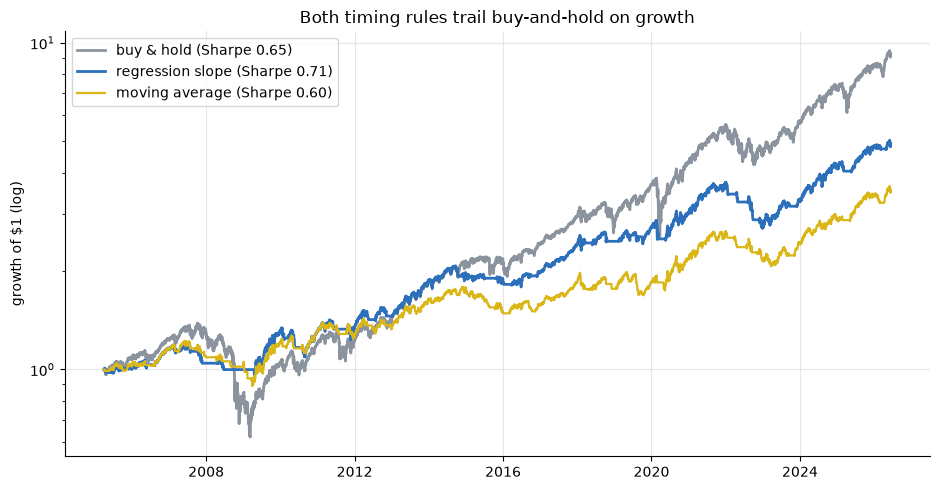

net CAGR -> slope 7.8%  movavg 6.2%  buy&hold 11.1%


In [2]:
if HAVE_REAL:
    sl = st.slope_signal(CLOSE, window=60); sm = st.sma_signal(CLOSE, window=60)
    bt_sl = st.backtest(CLOSE, sl, cost_bps=1.0); bt_sm = st.backtest(CLOSE, sm, cost_bps=1.0)
    eq_sl = (1+bt_sl['net']).cumprod(); eq_sm = (1+bt_sm['net']).cumprod()
    eq_bh = (1+bt_sl['asset_ret']).cumprod()
    fig, ax = plt.subplots()
    ax.plot(eq_bh.index, eq_bh, c=GREY, lw=2, label=f'buy & hold (Sharpe {R["sharpe_bh"]:.2f})')
    ax.plot(eq_sl.index, eq_sl, c='#2c6fbb', lw=2, label=f'regression slope (Sharpe {R["slope"]["sharpe"]:.2f})')
    ax.plot(eq_sm.index, eq_sm, c=AMBER, lw=1.6, label=f'moving average (Sharpe {R["sma"]["sharpe"]:.2f})')
    ax.set_yscale('log'); ax.set_ylabel('growth of \$1 (log)'); ax.legend()
    ax.set_title('Both timing rules trail buy-and-hold on growth')
    plt.tight_layout(); plt.show()
else:
    print('cache missing; headline: slope Sharpe', R['slope']['sharpe'], 'vs buy-hold', R['sharpe_bh'])
print(f"net CAGR -> slope {R['slope']['cagr_net']:.1f}%  movavg {R['sma']['cagr_net']:.1f}%  buy&hold {R['cagr_bh']:.1f}%")

On **growth**, buy-and-hold wins outright (**11.1%/yr** vs the slope rule's **7.8%**) — because sitting in cash 28% of the time during a bull market costs you. The slope rule's *risk-adjusted* number (Sharpe **0.71**) edges buy-and-hold's (**0.65**) only because it dodges some volatility. Is that tiny Sharpe edge real? That's the whole question.

**The decisive test.** Forget total return — look at the rule's **outperformance over buy-and-hold, day by day**. If the slope genuinely adds skill, those daily "active" returns should be reliably positive. Here's their average against a luck cloud built by **shuffling the rule's timing** (block-permutation): if the real bar sits inside the cloud, it's noise.

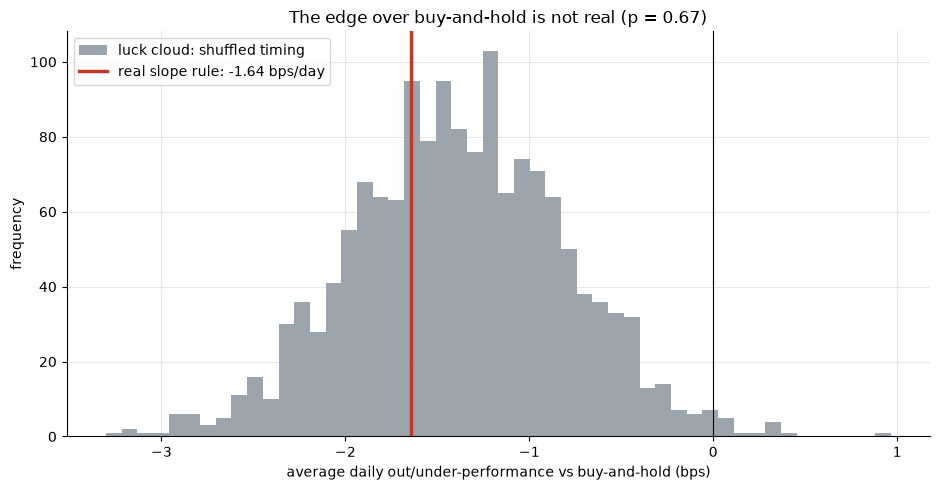

real active mean -1.64 bps/day  permutation p = 0.67  (a real edge would sit far RIGHT of the cloud)


In [3]:
if HAVE_REAL:
    perm = st.permutation_pvalue(CLOSE, st.slope_signal(CLOSE,60), n_draws=1500, cost_bps=1.0)
    obs = perm['obs']*1e4; draws = perm['draws']*1e4; pval = perm['p_value']
else:
    obs = R['perm_obs_bps']; pval = R['perm_p']
    rng = np.random.default_rng(439); draws = rng.normal(0, 2.0, 1500)
fig, ax = plt.subplots()
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='luck cloud: shuffled timing')
ax.axvline(obs, c=RED, lw=2.5, label=f'real slope rule: {obs:+.2f} bps/day')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('average daily out/under-performance vs buy-and-hold (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'The edge over buy-and-hold is not real (p = {pval:.2f})'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real active mean {obs:+.2f} bps/day  permutation p = {pval:.2f}  (a real edge would sit far RIGHT of the cloud)')

The red line sits **left of zero** and squarely inside the luck cloud (**p = 0.68**). The slope rule does not reliably beat the market it trades — its daily out-performance is *negative on average* and indistinguishable from a randomly-shuffled version of itself.

**Now the head-to-head the claim is really about: slope vs moving average.** Does the fancy regression actually do anything the crude average doesn't? We line up both rules' edge over buy-and-hold (their *t*-stat — anything below the dashed line means "doesn't beat the market").

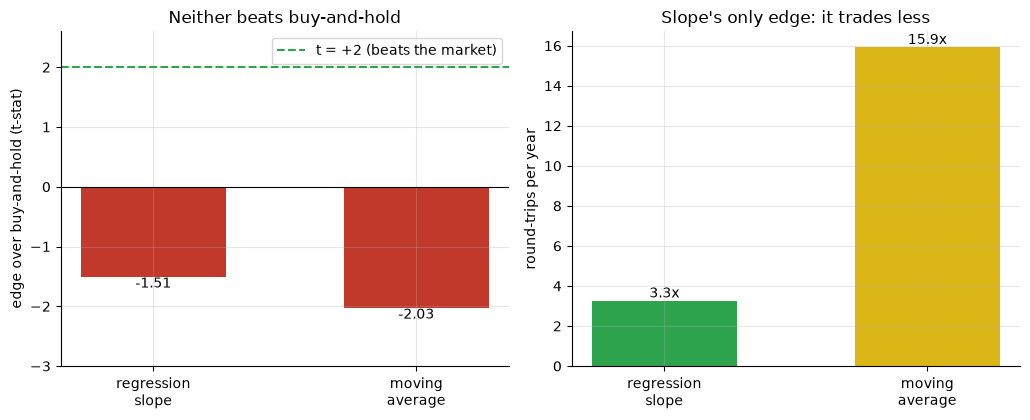

slope active-t -1.51 (turn 3.3/yr) | SMA active-t -2.03 (turn 15.9/yr)


In [4]:
rules = ['regression\nslope', 'moving\naverage']
tvals = [R['slope']['active_t'], R['sma']['active_t']]
turns = [R['slope']['turn_yr'], R['sma']['turn_yr']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.3))
a1.bar(rules, tvals, color=[RED, RED], width=.55)
a1.axhline(2, ls='--', c=GREEN, label='t = +2 (beats the market)'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(tvals): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='top',fontsize=10)
a1.set_ylabel('edge over buy-and-hold (t-stat)'); a1.set_ylim(-3, 2.6)
a1.set_title('Neither beats buy-and-hold'); a1.legend()
a2.bar(rules, turns, color=[GREEN, AMBER], width=.55)
for i,v in enumerate(turns): a2.annotate(f'{v:.1f}x',(i,v),ha='center',va='bottom',fontsize=10)
a2.set_ylabel('round-trips per year'); a2.set_title("Slope's only edge: it trades less")
plt.tight_layout(); plt.show()
print(f"slope active-t {R['slope']['active_t']:+.2f} (turn {R['slope']['turn_yr']:.1f}/yr) | "
      f"SMA active-t {R['sma']['active_t']:+.2f} (turn {R['sma']['turn_yr']:.1f}/yr)")

There's the verdict in one picture. **Neither** rule clears the green line — both have a *negative* edge over buy-and-hold (slope **-1.51**, moving average **-2.03**). The regression slope's *only* genuine difference is that it **trades ~5× less** (3.3 vs 15.9 round-trips a year) because the slope flips sign less often than price crosses its average. That's a smoothness property, not an edge.

## 5 · The verdict

- **Signal — None.** The slope rule's out-performance over buy-and-hold is *negative* and not significant (head-to-head *t* = **-1.51**, permutation **p = 0.68**). On 5 of 6 other names it loses to buy-and-hold.
- **Tradability — Mirage.** The wafer-thin SPY Sharpe edge (0.71 vs 0.65) isn't real, doesn't survive across names, and the long/short version is much worse.
- **"Beats a moving average"? — Not supported.** Both rules fail to beat the market; the slope's only real difference is *lower turnover*, not higher return. The regression line is a lagging average wearing a lab coat.

## 6 · Could you actually trade it? — it's not a cost problem

Sometimes a paper edge dies only because costs eat it. Not here — there's no edge to begin with. Even at **zero** cost the slope rule doesn't beat buy-and-hold, and crucially it **loses on almost every other instrument** we tried. Folklore that only "works" on the one ticker you picked is the oldest mirage in the book.

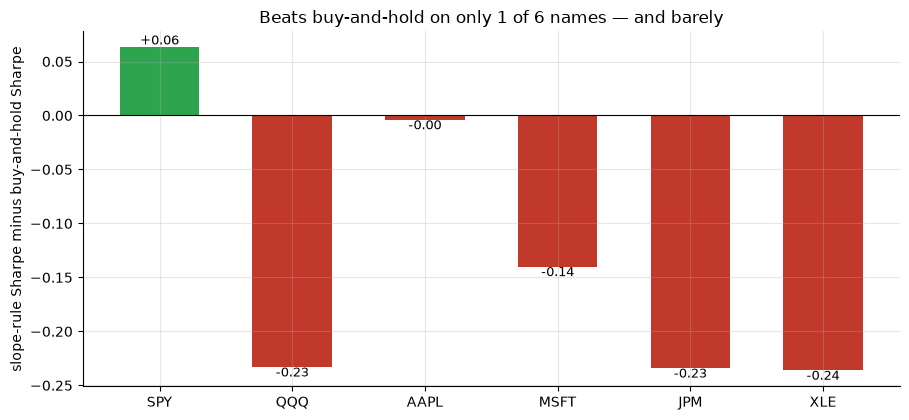

Sharpe gap vs buy-hold by name: {'SPY': 0.063, 'QQQ': -0.233, 'AAPL': -0.004, 'MSFT': -0.14, 'JPM': -0.234, 'XLE': -0.236}


In [5]:
names = [p[0] for p in R['panel']]; gaps = [p[3] for p in R['panel']]
cols = [GREEN if g>0 else RED for g in gaps]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(names, gaps, color=cols, width=.6); ax.axhline(0, c='k', lw=.8)
for i,g in enumerate(gaps): ax.annotate(f'{g:+.2f}',(i,g),ha='center',va='bottom' if g>0 else 'top',fontsize=9)
ax.set_ylabel('slope-rule Sharpe minus buy-and-hold Sharpe')
ax.set_title(f"Beats buy-and-hold on only {R['panel_beat']} of {R['panel_n']} names — and barely")
plt.tight_layout(); plt.show()
print('Sharpe gap vs buy-hold by name:', {p[0]: round(p[3],3) for p in R['panel']})

Only **SPY** is (barely) green, and even there the edge is statistical noise. The honest read: the Linear Regression Channel is a perfectly good *drawing tool* for visualising a trend — but as a timing signal on a liquid index it's a **Mirage**. You'd have done better, with less effort and lower taxes, by doing nothing.

## 7 · Going further 🚪

- **Channel bands, not just the slope.** The LRC also draws ±2σ bands around the line — a Bollinger-style mean-reversion play. That's a different claim (see desk study **104 — Bollinger-Reversion**); the *slope* tested here is the trend claim.
- **Other markets.** The slope rule earns its keep where trends are strong and persistent (some commodities, FX). On a mean-reverting, mostly-up equity index, staying invested wins.
- **Build your own.** Swap the 60-day window, try long/short, or race it against MACD/RSI — the harness in [`strategy.py`](../linear_regression_channel/strategy.py) makes it a one-liner.

*Think the slope beats a moving average somewhere it matters? Show the **net** active *t* over buy-and-hold clearing **+2**, on a market you didn't cherry-pick — then we'll talk.*